## Working With Images in Python

In this notebook we will explore working with images in Python. We will be introduced to commonly used libraries used for computer vision and some basic image operations.

What we will cover in this notebook:
- Introduction to Python libraries for image operations
- Loading and displaying images
- Understanding images as numerical matrices
- Understanding image channels

### OpenCV Library

OpenCV (Open Source Computer Vision Library) is a widely used open-source library for image and video processing. In image processing tasks, OpenCV represents images as multi-dimensional numerical arrays, enabling direct manipulation of pixel intensities and colour channels through mathematical operations. This makes it well suited for illustrating foundational concepts such as image representation, intensity transformations, and basic array operations.

More broadly, OpenCV provides efficient implementations of core image processing techniques, including filtering, convolution with kernels, and feature extraction. By offering a practical interface to these operations, the library allows theoretical concepts to be explored through concrete experiments, helping bridge the gap between mathematical formulations and their computational realisation.

Beyond image processing, OpenCV plays a central role in computer vision, providing tools for tasks such as feature detection, object recognition, and motion analysis, which will be explored later.

### Setup and Libraries

In [ ]:
# Link: https://pypi.org/project/opencv-python/
# ! pip install opencv-python
# ! pip install numpy, matplotlib, pandas

In [2]:
import cv2
print('opencv:',cv2.__version__)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

opencv: 4.13.0


### Images as Functions and Matrices



Computer algorithms treat images as numerical matrices. Let us use `open-cv` library to load a sample image and analyse the underlying numerical matrix.

**Loading and Displaying Images**

In [4]:
image_path = 'data/car.png'
image = cv2.imread(image_path)

We have successfully used openCV's `imread` function to load our image and store it in a variable called image. But how do we verify if the image is correctly loaded? Do we print the variable?

In [5]:
print(image.shape)

(137, 368, 3)


In [12]:
print(image)

[[[247 247 247]
  [247 247 247]
  [247 247 247]
  ...
  [247 247 247]
  [247 247 247]
  [247 247 247]]

 [[247 247 247]
  [247 247 247]
  [247 247 247]
  ...
  [247 247 247]
  [247 247 247]
  [247 247 247]]

 [[247 247 247]
  [247 247 247]
  [247 247 247]
  ...
  [247 247 247]
  [247 247 247]
  [247 247 247]]

 ...

 [[247 247 247]
  [247 247 247]
  [247 247 247]
  ...
  [247 247 247]
  [247 247 247]
  [247 247 247]]

 [[247 247 247]
  [247 247 247]
  [247 247 247]
  ...
  [247 247 247]
  [247 247 247]
  [247 247 247]]

 [[247 247 247]
  [247 247 247]
  [247 247 247]
  ...
  [247 247 247]
  [247 247 247]
  [247 247 247]]]


Actually no! If we print the image, we will get raw form of the image as an array or a list of pixel values. So, basically, an image is a function of pixel intensity values at each location of the image.

*The word pixel actually means picture elements!*

So, an image is actually a collection of all those pixel intensity values represented by $I(x,y)$. Here, we see a 3D arraywith shape `(rows, columns, channels)`

- The outermost dimension corresponds to the rows of the image (height)
- The second dimension corresponds to the columns of the image (width)
- The innermost dimension represents the colour channels of a single pixel

Each pixel is represented by three values (e.g. `[247, 247, 247]`), which correspond to the BGR (Blue, Green, Red) intensity values in OpenCV, not RGB.

But the question still remains how do we display the image?

In [6]:
cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

array([[[247, 247, 247],
        [247, 247, 247],
        [247, 247, 247],
        ...,
        [247, 247, 247],
        [247, 247, 247],
        [247, 247, 247]],

       [[247, 247, 247],
        [247, 247, 247],
        [247, 247, 247],
        ...,
        [247, 247, 247],
        [247, 247, 247],
        [247, 247, 247]],

       [[247, 247, 247],
        [247, 247, 247],
        [247, 247, 247],
        ...,
        [247, 247, 247],
        [247, 247, 247],
        [247, 247, 247]],

       ...,

       [[247, 247, 247],
        [247, 247, 247],
        [247, 247, 247],
        ...,
        [247, 247, 247],
        [247, 247, 247],
        [247, 247, 247]],

       [[247, 247, 247],
        [247, 247, 247],
        [247, 247, 247],
        ...,
        [247, 247, 247],
        [247, 247, 247],
        [247, 247, 247]],

       [[247, 247, 247],
        [247, 247, 247],
        [247, 247, 247],
        ...,
        [247, 247, 247],
        [247, 247, 247],
        [247, 247, 247]]

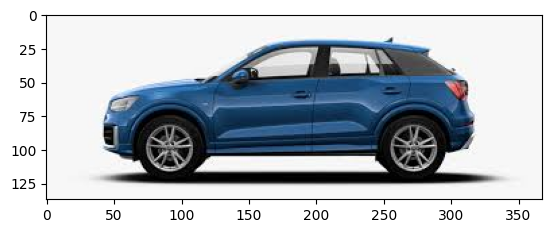

In [7]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

Ah, now we see our blue car! But did you notice we used another function `cv2.cvtColor(image, cv2.COLOR_BGR2RGB)`, within `plt.imshow()`. Do you know why? Let's use `plt.imshow()` without the other function and let's see the difference.

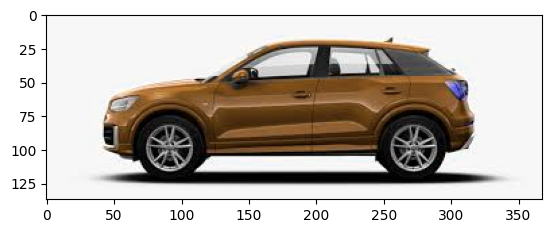

In [8]:
plt.imshow(image)

How did our blue car changed to a brown one with a blue back light instead of red? As we mentioned earlier, `plt.imshow()` by default displays the images in BGR format instead of RGB.

**[RGB (Red, Green, Blue) are the three colour channels of a coloured imaged]**

So, we would have to explicity do a colour conversion and display the images in the correct format. And hence we will use `cv2.cvtColor()` for doing this conversion. Now, let's prepare a small utility function which we can call any time, to do this conversion.

(137, 368, 3)


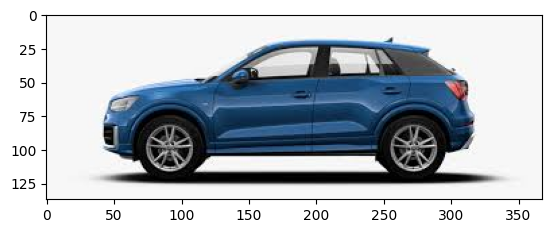

In [10]:
# Utility function to display images
def show_image(img, fig_size = None):
    print(img.shape)
    img = img.astype('uint8')

    if fig_size is not None:
        plt.figure(figsize=fig_size)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.show()

show_image(image)

**Image Dimensions and Data Types**

In [16]:
print('Shape:',image.shape)
print('Data type:', type(image))
print('Each element type:',image.dtype)
print('max pixel value:', np.max(image))
print('min pixel value:', np.min(image))

Shape: (137, 368, 3)
Data type: <class 'numpy.ndarray'>
Each element type: uint8
max pixel value: 255
min pixel value: 0


Another important fact which might come in handy later - Since, our pixel values are of type `uint8`, if we add 1, to the brightest pixel, which is 255, the value won't change to 256 (it won't get any brighter) rather it will change to 0.

So, 255 + 1 = 0 in the unsigned `int8` world! And similarly, if we subtract 1 from the darkest pixel 0, it will be 255.

**Colour Images and extracting channels from image**

In [17]:
# Utility Functions - to convert coloured images to gray scale
def to_gray_scale(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray

(137, 368)


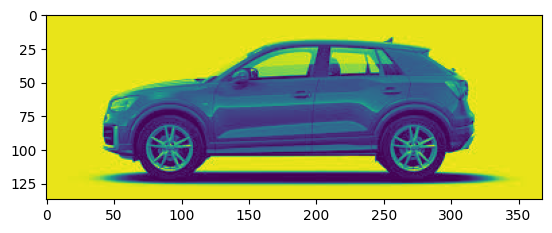

In [14]:
# gray_scaled_image = to_gray_scale(image)
gray_scaled_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# show_image(gray_scaled_image)
plt.imshow(gray_scaled_image)
# plt.imshow(cv2.cvtColor(gray_scaled_image, cv2.COLOR_BGR2RGB))
print(gray_scaled_image.shape)

(137, 368)


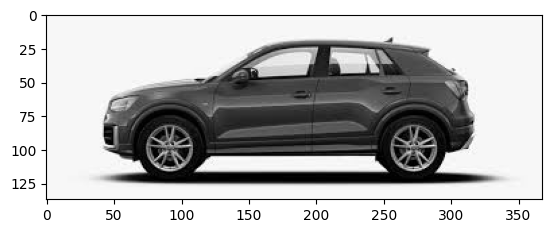

In [15]:
# gray_scaled_image = to_gray_scale(image)
gray_scaled_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# show_image(gray_scaled_image)
plt.imshow(cv2.cvtColor(gray_scaled_image, cv2.COLOR_BGR2RGB))
print(gray_scaled_image.shape)

In [18]:
# Utility Functions - to convert coloured images to monochrome image
def to_monochrome(img, channel = 'R'):
    if channel == 'R':
        monochrome = img[:,:,2]
    if channel == 'G':
        monochrome = img[:,:,1]
    if channel == 'B':
        monochrome = img[:,:,0]

    return monochrome

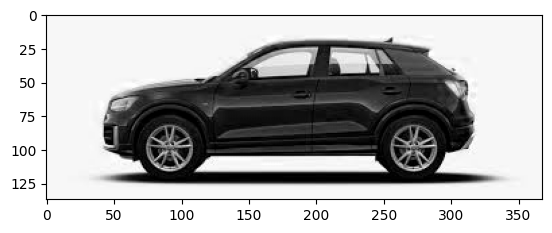

(137, 368)


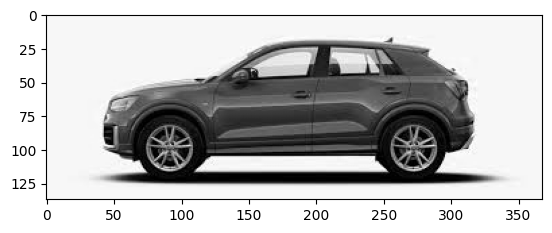

(137, 368)


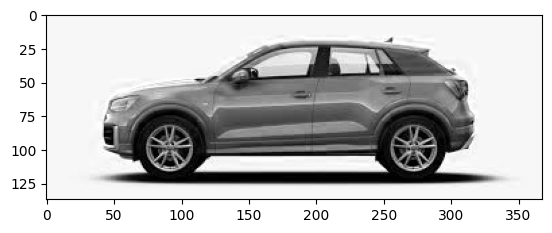

In [23]:
# Red Monochrome
# show_image(to_monochrome(image,channel = 'R'))
plt.imshow(cv2.cvtColor(image[:,:,2], cv2.COLOR_BGR2RGB))
plt.show()
# Green Monochrome
show_image(to_monochrome(image,channel = 'G'))
# # Blue Monochrome
show_image(to_monochrome(image,channel = 'B'))

In [24]:
# Utility Functions - to swap colour channels
# def swap_color_channels(img, channel1 = 'R', channel2 = 'B'):
#     duplicate = img.copy()

#     dict_color = {'R':2,'G':1,'B':0}

#     temp = duplicate[:,:,dict_color[channel1]].copy()
#     duplicate[:,:,dict_color[channel1]] = duplicate[:,:,dict_color[channel2]].copy()
#     duplicate[:,:,dict_color[channel2]] = temp.copy()

#     return duplicate

def swap_color_channels(img, channel1='R', channel2='B'):
    ch = {'R': 2, 'G': 1, 'B': 0}
    out = img.copy()
    c1, c2 = ch[channel1], ch[channel2]
    out[:, :, c1], out[:, :, c2] = out[:, :, c2].copy(), out[:, :, c1].copy()
    return out

(137, 368, 3)


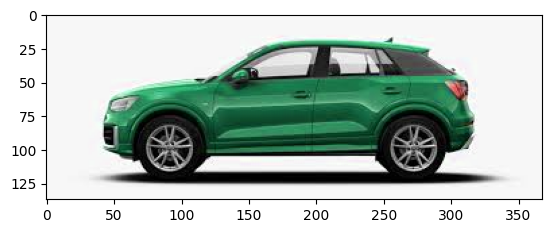

(137, 368, 3)


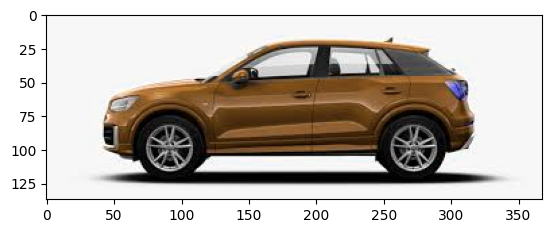

In [25]:
# Swap Blue and Green channels
show_image(swap_color_channels(image,channel1 = 'B', channel2 = 'G'))

# Swap Blue and Red channels
show_image(swap_color_channels(image,channel1 = 'B', channel2 = 'R'))

This brings us to the end of this notebook. In this notebook, we explored how to load images with `open-cv` in Python. After loading and displaying our sample image, we represented it as a numerical matrix of pixel intensity values. We also explored the image dimensions and the default unsigned int 8 data type for images. Finally, we saw the difference between a gray scaled image vs RGB images and learned to extract the individual colour channels.